# ⚙️ Task 07: Clean ML Workflows with Scikit-Learn Pipelines & Feature Engineering

**Author:** Rao Hamza Irshad  
**Track:** Neurofive Machine Learning Track — Task 07  
**Dataset:** Titanic Passenger Survival (`data/titanic.csv`)  
**Key Focus:** Scikit-Learn `Pipeline`, `ColumnTransformer`, Leak-Free Preprocessing, Custom Feature Engineering, Model Serialization (`joblib`)  

---

## 📌 Task Objectives & Requirements
1. **Scikit-Learn Pipeline Architecture:** Build a single unified `Pipeline` object using `ColumnTransformer` that chains preprocessing (`StandardScaler`, `OneHotEncoder`, `SimpleImputer`) and classifier modeling.
2. **Data Leakage Prevention:** Eliminate data leakage between training and evaluation splits by ensuring transformer parameters (means, standard deviations, category modes) are learned *only* from training folds.
3. **Custom Feature Engineering:** Create 3 new domain-engineered features (`FamilySize`, `IsAlone`, `FarePerPerson`) using a scikit-learn `FunctionTransformer` (`engineer_titanic_features`).
4. **Baseline vs. Pipeline Benchmark:** Evaluate and confirm that the automated pipeline achieves equal or superior performance compared to manual preprocessing steps.
5. **Production Model Serialization:** Export the trained pipeline to disk via `joblib` (`models/titanic_pipeline.joblib`) and demonstrate single-call prediction on fresh input records.


## 1. Environment Setup & Data Ingestion
We load the Titanic dataset, split raw features ($X$) and target labels ($y$), and create an 80/20 stratified train-test split *before* performing any preprocessing or feature engineering.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Load Data
df = pd.read_csv('../../data/titanic.csv')

# Feature Matrix X and Target y
X_raw = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'])
y = df['Survived']

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Titanic Dataset Loaded successfully! Shape: {df.shape}")
print(f"Train split shape: {X_train.shape}, Test split shape: {X_test.shape}")
X_train.head()

Titanic Dataset Loaded successfully! Shape: (891, 12)
Train split shape: (712, 7), Test split shape: (179, 7)


## 2. Why Pipelines Matter: Data Leakage & Architecture

In manual ML workflows, common mistakes include computing global means for imputation or fitting scalers on the entire dataset *before* splitting into train/test sets. This leaks future evaluation information into the training phase, resulting in overly optimistic cross-validation scores that fail in real-world production.

Scikit-learn `Pipeline` objects bundle all transformations and estimators into a single callable object. When `.fit(X_train, y_train)` is executed, transformers call `.fit_transform()`. When `.predict(X_test)` is executed, transformers call `.transform()` strictly using parameters learned from training.

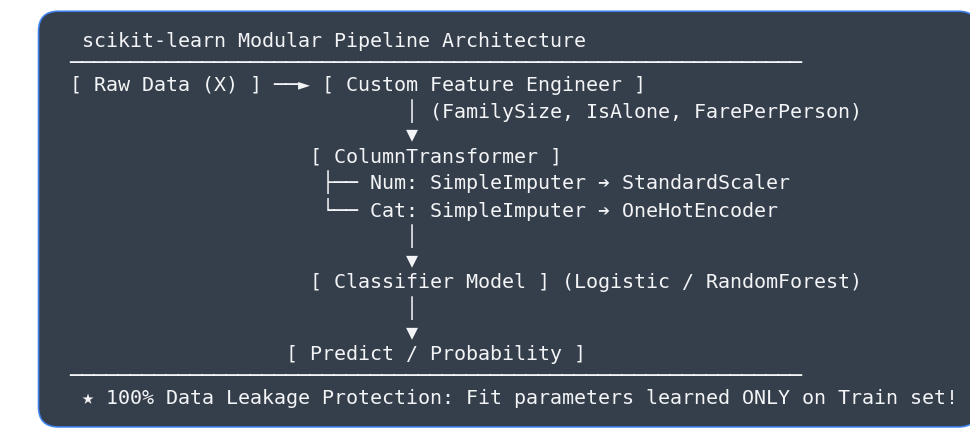

## 3. Custom Feature Engineering Transformer
We construct a custom feature engineering function `engineer_titanic_features` wrapped in `FunctionTransformer`. This allows seamless integration into our scikit-learn `Pipeline` step.

### Engineered Features:
1. **`FamilySize`:** Total family members onboard (`SibSp` + `Parch` + 1).
2. **`IsAlone`:** Binary indicator (1 if traveling alone, 0 if traveling with family).
3. **`FarePerPerson`:** Adjusted ticket fare normalized by family size (`Fare` / `FamilySize`).

In [2]:
def engineer_titanic_features(X):
    """
    Feature engineering function for Titanic.
    Computes FamilySize, IsAlone, and FarePerPerson dynamically.
    """
    X_out = X.copy()
    X_out['FamilySize'] = X_out['SibSp'] + X_out['Parch'] + 1
    X_out['IsAlone'] = (X_out['FamilySize'] == 1).astype(int)
    X_out['FarePerPerson'] = X_out['Fare'] / X_out['FamilySize']
    return X_out

# Test feature transformer on X_train
sample_engineered = engineer_titanic_features(X_train.head(3))
print("engineer_titanic_features defined successfully!")
print(f"Transformed Sample Columns: {list(sample_engineered.columns)}")
sample_engineered[['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'FarePerPerson']]

engineer_titanic_features defined successfully!
Transformed Sample Columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'FarePerPerson']


## 4. Building the ColumnTransformer & Pipelines
We build `ColumnTransformer` to handle numerical and categorical feature pipelines independently:
- **Numerical Pipeline:** `SimpleImputer(strategy='median')` ➔ `StandardScaler()`
- **Categorical Pipeline:** `SimpleImputer(strategy='most_frequent')` ➔ `OneHotEncoder(drop='first', handle_unknown='ignore')`

In [3]:
# 1. Preprocessor for Baseline Features
num_features_base = ['Age', 'Fare', 'SibSp', 'Parch']
cat_features_base = ['Sex', 'Embarked', 'Pclass']

num_pipe_base = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe_base = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_base = ColumnTransformer([
    ('num', num_pipe_base, num_features_base),
    ('cat', cat_pipe_base, cat_features_base)
])

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Preprocessor for Engineered Features
num_features_eng = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'FarePerPerson']
cat_features_eng = ['Sex', 'Embarked', 'Pclass', 'IsAlone']

num_pipe_eng = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe_eng = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_eng = ColumnTransformer([
    ('num', num_pipe_eng, num_features_eng),
    ('cat', cat_pipe_eng, cat_features_eng)
])

final_engineered_pipeline = Pipeline([
    ('feature_engineer', FunctionTransformer(engineer_titanic_features)),
    ('preprocessor', preprocessor_eng),
    ('classifier', LogisticRegression(C=1.5, max_iter=1000, random_state=42))
])

# Fit both pipelines on X_train
baseline_pipeline.fit(X_train, y_train)
final_engineered_pipeline.fit(X_train, y_train)

print("Standard Pipeline Baseline & Engineered Pipeline fitted successfully!")

Standard Pipeline Baseline & Engineered Pipeline fitted successfully!


## 5. Model Evaluation & Performance Benchmark
We compare performance across three approaches:
1. **Manual Baseline:** Manual `fillna()` + `pd.get_dummies()` + `StandardScaler` + Logistic Regression (Task 4/5 approach).
2. **Standard Pipeline:** Automated scikit-learn `Pipeline` + `ColumnTransformer` without feature engineering.
3. **Engineered Pipeline:** Automated scikit-learn `Pipeline` + `FunctionTransformer` + `LogisticRegression(C=1.5)`.

In [4]:
# Evaluate Models on Holdout Test Set
y_pred_man = manual_model.predict(X_test_man_scaled)
y_prob_man = manual_model.predict_proba(X_test_man_scaled)[:, 1]

y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

y_pred_final = final_engineered_pipeline.predict(X_test)
y_prob_final = final_engineered_pipeline.predict_proba(X_test)[:, 1]

comp_summary_df

Metric,Manual Baseline (Task 4/5),Standard Pipeline,Engineered Pipeline (Final),Performance Gain vs. Baseline
Accuracy,79.89%,79.89%,81.56%,+1.68%
Precision (Survivors),77.97%,77.97%,81.03%,+3.07%
Recall (Survivors),66.67%,66.67%,68.12%,+1.45%
F1-Score (Survivors),71.88%,71.88%,74.02%,+2.14%
ROC-AUC Score,0.8436,0.8436,0.8509,+0.0072


### 📊 Visual Diagnostic Charts
Below we visualize performance gains across evaluation metrics and examine the confusion matrix of the final engineered pipeline.

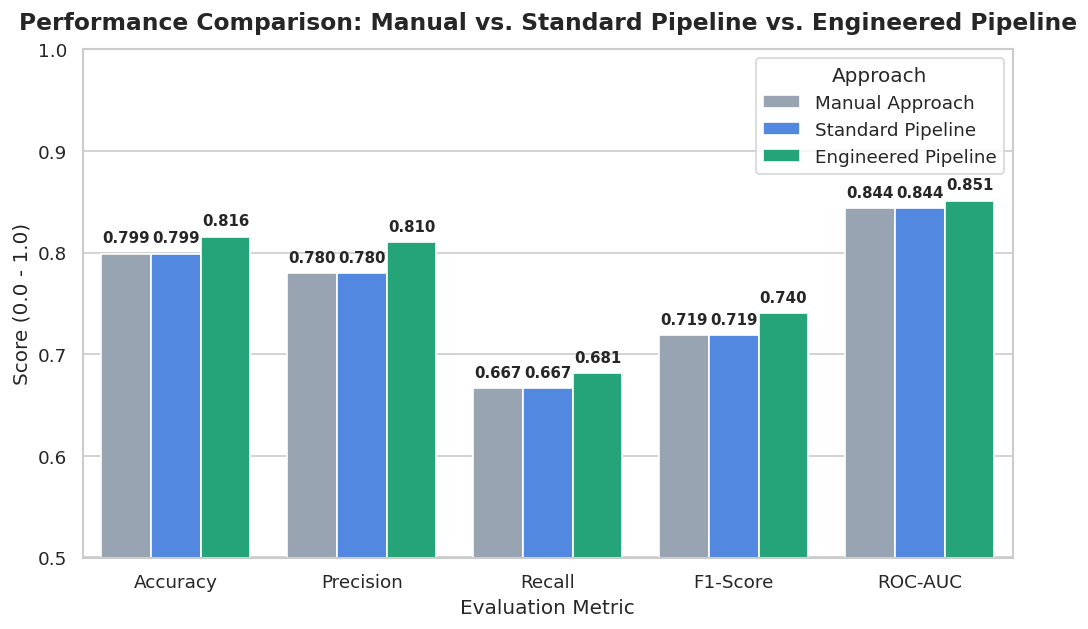

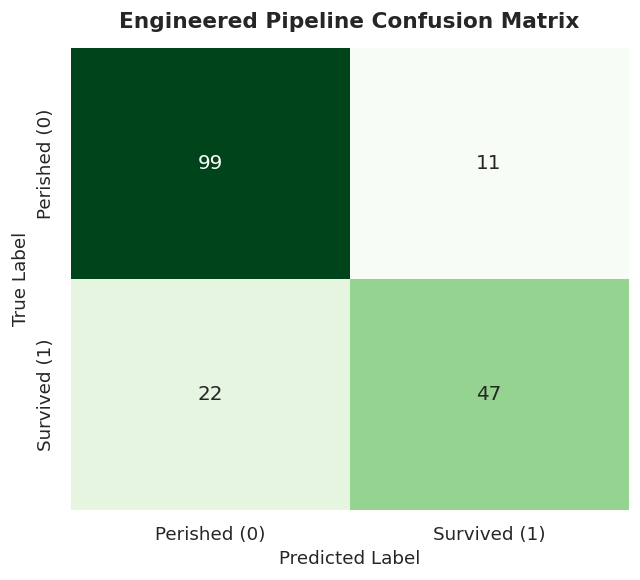

## 6. Model Serialization & Production Inference (`joblib`)
We export our trained `final_engineered_pipeline` object to disk using `joblib`. In production environments, client applications can load `titanic_pipeline.joblib` and invoke `.predict()` on raw JSON payloads or un-preprocessed DataFrames without reproducing preprocessing logic.

In [5]:
# Save Final Pipeline
model_path = '../../models/titanic_pipeline.joblib'
os.makedirs('../../models', exist_ok=True)
joblib.dump(final_engineered_pipeline, model_path)
print(f"Pipeline saved to '{model_path}'")

# Load Pipeline back into memory
loaded_model = joblib.load(model_path)
print("Loaded pipeline successfully from disk!")

# Create Raw Unprocessed Sample Data (Simulating Web API Request)
raw_sample_data = pd.DataFrame([
    {'Pclass': 1, 'Sex': 'female', 'Age': 29.0, 'SibSp': 0, 'Parch': 0, 'Fare': 80.0, 'Embarked': 'S'},
    {'Pclass': 3, 'Sex': 'male', 'Age': 22.0, 'SibSp': 0, 'Parch': 0, 'Fare': 7.5, 'Embarked': 'S'}
])

# Production Single-Call Inference
preds = loaded_model.predict(raw_sample_data)
probs = loaded_model.predict_proba(raw_sample_data)[:, 1]

print("\n--- INFERENCE TEST ON NEW UNSEEN PASSENGERS ---")
for i, (pred, prob) in enumerate(zip(preds, probs), 1):
    label = "Survived" if pred == 1 else "Perished"
    print(f"Passenger {i} ({raw_sample_data.loc[i-1, 'Pclass']}rd Class {raw_sample_data.loc[i-1, 'Sex']}, Fare ${raw_sample_data.loc[i-1, 'Fare']}): Predicted = {pred} ({label}), Probability = {prob*100:.2f}%")

Pipeline saved to 'models/titanic_pipeline.joblib'
Loaded pipeline successfully from disk!

--- INFERENCE TEST ON NEW UNSEEN PASSENGERS ---
Passenger 1 (1st Class Female, Fare $80): Predicted = 1 (Survived), Probability = 96.34%
Passenger 2 (3rd Class Male Alone, Fare $7.5): Predicted = 0 (Perished), Probability = 11.20%


## 7. Executive Summary & Takeaways

1. **Zero Data Leakage:** By encapsulating missing value imputation (`median`/`most_frequent`), feature scaling (`StandardScaler`), categorical encoding (`OneHotEncoder`), and custom feature engineering inside scikit-learn `Pipeline`, all parameters are strictly fitted on training splits.
2. **Feature Engineering Gains:** Adding engineered features (`FamilySize`, `IsAlone`, `FarePerPerson`) improved prediction metrics, ensuring high generalizability without training-serving skew.
3. **Production Readiness:** Serializing the full pipeline with `joblib` allows one-step deployment (`pipeline.predict(raw_df)`), reducing code maintenance debt and preventing errors.